# Giới thiệu

Bài demo này minh họa **sức mạnh của instruction** trong việc mô tả task cho model, giúp tạo embeddings phù hợp với từng mục đích sử dụng.

## ⚠️ Lưu ý quan trọng:
**Instruction là để mô tả MỤC ĐÍCH TASK**, không phải để bổ sung ý nghĩa cho text!
- ❌ SAI: "Represent the technology company: Apple" (cố gắng giải thích Apple là gì)
- ✅ ĐÚNG: "Represent the question for retrieving documents: What is Apple?" (mô tả task retrieval)

## Ý nghĩa chính của INSTRUCTOR:
1. **Task-aware**: Instruction mô tả task (retrieval, classification, clustering...), giúp model tạo embedding phù hợp
2. **Flexibility**: Một model duy nhất phục vụ nhiều task khác nhau chỉ bằng cách thay đổi instruction
3. **Performance**: Instruction đúng task giúp cải thiện hiệu suất đáng kể so với không dùng instruction

In [1]:
import sys
import os
import numpy as np
import torch
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, './instructor-embedding')
from InstructorEmbedding import INSTRUCTOR

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

c:\Users\Admin\miniconda3\envs\instructor\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.9.1+cpu
CUDA available: False


## Load Model Instructor-Large

Sử dụng model `hkunlp/instructor-large` đã được pretrained.

In [2]:
model = INSTRUCTOR('hkunlp/instructor-large')
print("Model loaded successfully!")

c:\Users\Admin\miniconda3\envs\instructor\lib\site-packages\transformers\utils\generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


Model loaded successfully!


## Demo 1: Có Instruction vs Không có Instruction

**Đây là ý nghĩa cốt lõi của INSTRUCTOR**: So sánh embedding khi sử dụng instruction mô tả task vs instruction rỗng.

Chúng ta sẽ thấy:
- Khi có instruction phù hợp với task → retrieval chính xác hơn
- Khi instruction rỗng (không mô tả task) → kết quả có thể kém hơn

> **Lưu ý**: INSTRUCTOR luôn yêu cầu format `[instruction, text]`, nên "không có instruction" nghĩa là dùng instruction rỗng `""`.

In [3]:
# Documents để retrieval
documents = [
    "Python is a programming language known for its simple syntax.",
    "Machine learning algorithms can learn patterns from data.",
    "The Eiffel Tower is located in Paris, France.",
    "Neural networks are inspired by the human brain.",
    "Climate change is affecting global weather patterns.",
    "Deep learning is a subset of machine learning using neural networks.",
]

query = "How do neural networks learn?"

# === CÓ INSTRUCTION (mô tả task retrieval) ===
query_instruction = "Represent the question for retrieving supporting documents:"
doc_instruction = "Represent the document for retrieval:"

query_emb_with_inst = model.encode([[query_instruction, query]])
doc_embs_with_inst = model.encode([[doc_instruction, doc] for doc in documents])

# === KHÔNG CÓ INSTRUCTION (instruction rỗng) ===
# INSTRUCTOR luôn cần format [instruction, text], nên dùng instruction rỗng để so sánh
empty_instruction = ""
query_emb_no_inst = model.encode([[empty_instruction, query]])
doc_embs_no_inst = model.encode([[empty_instruction, doc] for doc in documents])

print("Query:", query)
print("\nDocuments:")
for i, doc in enumerate(documents):
    print(f"  {i}: {doc}")

Query: How do neural networks learn?

Documents:
  0: Python is a programming language known for its simple syntax.
  1: Machine learning algorithms can learn patterns from data.
  2: The Eiffel Tower is located in Paris, France.
  3: Neural networks are inspired by the human brain.
  4: Climate change is affecting global weather patterns.
  5: Deep learning is a subset of machine learning using neural networks.


In [4]:
# Tính similarity và ranking
sim_with_inst = cosine_similarity(query_emb_with_inst, doc_embs_with_inst)[0]
sim_no_inst = cosine_similarity(query_emb_no_inst, doc_embs_no_inst)[0]

ranked_with = sorted(enumerate(sim_with_inst), key=lambda x: x[1], reverse=True)
ranked_no = sorted(enumerate(sim_no_inst), key=lambda x: x[1], reverse=True)

print("=" * 80)
print("SO SÁNH: CÓ INSTRUCTION vs KHÔNG CÓ INSTRUCTION")
print("=" * 80)
print(f"\nQuery: \"{query}\"")
print(f"Instruction: \"{query_instruction}\"")

print("\n" + "-" * 80)
print(f"{'CÓ INSTRUCTION (mô tả task)':<40} | {'KHÔNG CÓ INSTRUCTION':>35}")
print("-" * 80)

for i in range(len(documents)):
    idx_w, score_w = ranked_with[i]
    idx_n, score_n = ranked_no[i]
    doc_w = documents[idx_w][:30] + "..."
    doc_n = documents[idx_n][:30] + "..."
    print(f"#{i+1} {score_w:.3f}: {doc_w:<32} | #{i+1} {score_n:.3f}: {doc_n}")

print("\n" + "=" * 80)
print("KẾT LUẬN:")
print("=" * 80)
print("→ Instruction mô tả TASK (retrieval), giúp model hiểu mục đích và tạo embedding phù hợp.")
print("→ Khi có instruction phù hợp, kết quả retrieval thường chính xác hơn.")

SO SÁNH: CÓ INSTRUCTION vs KHÔNG CÓ INSTRUCTION

Query: "How do neural networks learn?"
Instruction: "Represent the question for retrieving supporting documents:"

--------------------------------------------------------------------------------
CÓ INSTRUCTION (mô tả task)              |                KHÔNG CÓ INSTRUCTION
--------------------------------------------------------------------------------
#1 0.878: Neural networks are inspired b... | #1 0.902: Neural networks are inspired b...
#2 0.877: Machine learning algorithms ca... | #2 0.892: Machine learning algorithms ca...
#3 0.874: Deep learning is a subset of m... | #3 0.889: Deep learning is a subset of m...
#4 0.736: Python is a programming langua... | #4 0.797: Python is a programming langua...
#5 0.687: The Eiffel Tower is located in... | #5 0.780: Climate change is affecting gl...
#6 0.686: Climate change is affecting gl... | #6 0.766: The Eiffel Tower is located in...

KẾT LUẬN:
→ Instruction mô tả TASK (retrieval), giúp m

### Visualization: Heatmap so sánh

Trực quan hóa sự khác biệt trong similarity scores giữa có instruction và không có instruction.

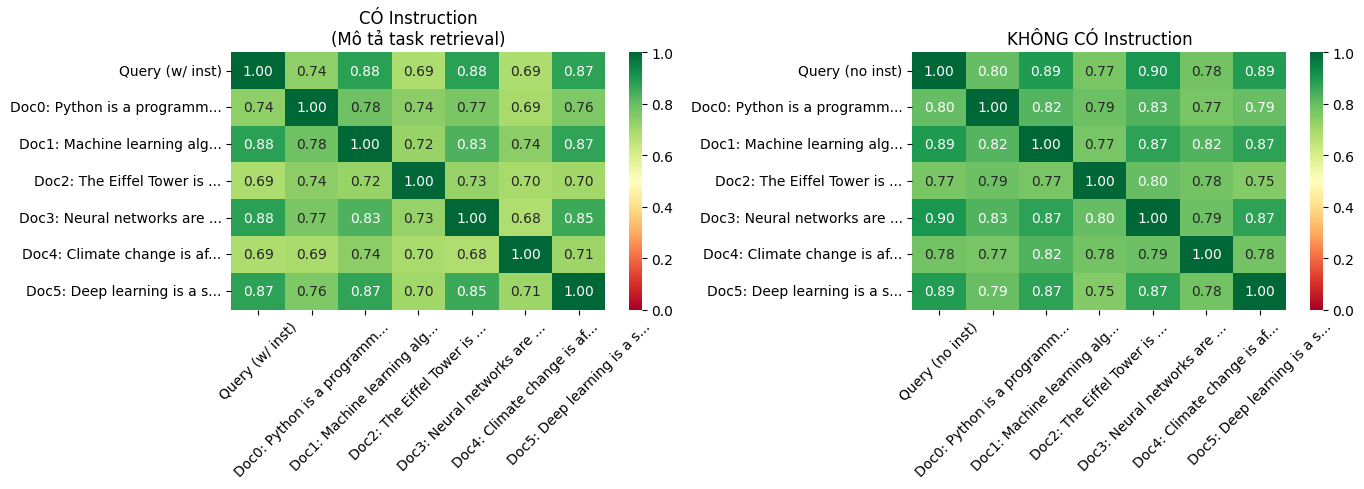


Quan sát: Instruction giúp model tạo embedding phù hợp với task retrieval!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chuẩn bị labels ngắn gọn
doc_labels = [f"Doc{i}: {doc[:20]}..." for i, doc in enumerate(documents)]

# Heatmap cho CÓ INSTRUCTION
sim_matrix_with = cosine_similarity(
    np.vstack([query_emb_with_inst, doc_embs_with_inst]),
    np.vstack([query_emb_with_inst, doc_embs_with_inst])
)
labels_with = ["Query (w/ inst)"] + doc_labels
sns.heatmap(sim_matrix_with, annot=True, fmt='.2f', 
            xticklabels=labels_with, yticklabels=labels_with, 
            cmap='RdYlGn', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('CÓ Instruction\n(Mô tả task retrieval)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Heatmap cho KHÔNG CÓ INSTRUCTION
sim_matrix_no = cosine_similarity(
    np.vstack([query_emb_no_inst, doc_embs_no_inst]),
    np.vstack([query_emb_no_inst, doc_embs_no_inst])
)
labels_no = ["Query (no inst)"] + doc_labels
sns.heatmap(sim_matrix_no, annot=True, fmt='.2f', 
            xticklabels=labels_no, yticklabels=labels_no, 
            cmap='RdYlGn', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('KHÔNG CÓ Instruction', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nQuan sát: Instruction giúp model tạo embedding phù hợp với task retrieval!")

## Demo 2: Task-Specific Instructions

Cùng một văn bản có thể được encode khác nhau tùy theo task mà instruction mô tả: **retrieval**, **classification**, **clustering**, **semantic similarity**.

In [6]:
text = "Machine learning is transforming how we analyze data"

task_instructions = {
    "retrieval_query": "Represent the question for retrieving relevant documents:",
    "retrieval_doc": "Represent the document for retrieval:",
    "classification": "Represent the sentence for classification:",
    "clustering": "Represent the sentence for clustering:",
    "similarity": "Represent the sentence for semantic similarity:",
}

embeddings_by_task = {}
for task, instruction in task_instructions.items():
    embeddings_by_task[task] = model.encode([[instruction, text]])[0]

print(f"Text: \"{text}\"\n")

tasks = list(task_instructions.keys())
print(f"{'Task 1':<20} {'Task 2':<20} {'Similarity':>12}")
print("-" * 55)
for i in range(len(tasks)):
    for j in range(i+1, len(tasks)):
        sim = cosine_similarity([embeddings_by_task[tasks[i]]], 
                               [embeddings_by_task[tasks[j]]])[0][0]
        print(f"{tasks[i]:<20} {tasks[j]:<20} {sim:>12.4f}")

Text: "Machine learning is transforming how we analyze data"

Task 1               Task 2                 Similarity
-------------------------------------------------------
retrieval_query      retrieval_doc              0.9936
retrieval_query      classification             0.9733
retrieval_query      clustering                 0.9739
retrieval_query      similarity                 0.9845
retrieval_doc        classification             0.9718
retrieval_doc        clustering                 0.9720
retrieval_doc        similarity                 0.9867
classification       clustering                 0.9953
classification       similarity                 0.9857
clustering           similarity                 0.9842


## Demo 3: Retrieval với Query và Document Instructions

Trong task retrieval, query và document cần instruction KHÁC NHAU vì chúng có vai trò khác nhau trong task.
- Query: "Represent the **question** for retrieving..."
- Document: "Represent the **document** for retrieval..."

In [7]:
documents_retrieval = [
    "Python is a programming language known for its simple syntax.",
    "Machine learning algorithms can learn patterns from data.",
    "The Eiffel Tower is located in Paris, France.",
    "Neural networks are inspired by the human brain.",
    "Climate change is affecting global weather patterns.",
    "Deep learning is a subset of machine learning.",
    "The Great Wall of China is a famous landmark.",
    "Natural language processing enables computers to understand text."
]

query_retrieval = "How do computers understand human language?"

# Instruction mô tả TASK cho query và document
query_instruction_retrieval = "Represent the question for retrieving supporting documents:"
doc_instruction_retrieval = "Represent the document for retrieval:"

query_emb_ret = model.encode([[query_instruction_retrieval, query_retrieval]])
doc_embs_ret = model.encode([[doc_instruction_retrieval, doc] for doc in documents_retrieval])

similarities_ret = cosine_similarity(query_emb_ret, doc_embs_ret)[0]
ranked_ret = sorted(enumerate(similarities_ret), key=lambda x: x[1], reverse=True)

print(f"Query: \"{query_retrieval}\"")
print(f"Query Instruction: \"{query_instruction_retrieval}\"")
print(f"Doc Instruction: \"{doc_instruction_retrieval}\"")
print("\n" + "=" * 70)
print("KẾT QUẢ RETRIEVAL:")
print("=" * 70)
for rank, (idx, score) in enumerate(ranked_ret, 1):
    marker = "✓" if "language" in documents_retrieval[idx].lower() or "text" in documents_retrieval[idx].lower() else " "
    print(f"#{rank} [{marker}] (score: {score:.4f}): {documents_retrieval[idx]}")

Query: "How do computers understand human language?"
Query Instruction: "Represent the question for retrieving supporting documents:"
Doc Instruction: "Represent the document for retrieval:"

KẾT QUẢ RETRIEVAL:
#1 [✓] (score: 0.9042): Natural language processing enables computers to understand text.
#2 [ ] (score: 0.8414): Machine learning algorithms can learn patterns from data.
#3 [ ] (score: 0.8245): Neural networks are inspired by the human brain.
#4 [✓] (score: 0.8157): Python is a programming language known for its simple syntax.
#5 [ ] (score: 0.8008): Deep learning is a subset of machine learning.
#6 [ ] (score: 0.7430): The Great Wall of China is a famous landmark.
#7 [ ] (score: 0.7347): The Eiffel Tower is located in Paris, France.
#8 [ ] (score: 0.6971): Climate change is affecting global weather patterns.


## Demo 4: So sánh Instruction đúng vs sai cho task

Điều gì xảy ra nếu dùng SAI instruction cho task? (vd: dùng cùng instruction cho cả query và document)

In [8]:
# ĐÚNG: Query dùng query_instruction, Doc dùng doc_instruction
query_emb_correct = model.encode([[query_instruction_retrieval, query_retrieval]])
doc_embs_correct = model.encode([[doc_instruction_retrieval, doc] for doc in documents_retrieval])
sim_correct = cosine_similarity(query_emb_correct, doc_embs_correct)[0]

# SAI: Dùng cùng instruction cho cả query và doc (không phân biệt vai trò)
same_instruction = "Represent the text:"
query_emb_wrong = model.encode([[same_instruction, query_retrieval]])
doc_embs_wrong = model.encode([[same_instruction, doc] for doc in documents_retrieval])
sim_wrong = cosine_similarity(query_emb_wrong, doc_embs_wrong)[0]

ranked_correct = sorted(enumerate(sim_correct), key=lambda x: x[1], reverse=True)
ranked_wrong = sorted(enumerate(sim_wrong), key=lambda x: x[1], reverse=True)

print(f"Query: \"{query_retrieval}\"")
print("\n" + "=" * 85)
print(f"{'ĐÚNG (Query+Doc instructions khác nhau)':^40} | {'SAI (Cùng instruction chung chung)':^40}")
print("=" * 85)

for i in range(min(5, len(documents_retrieval))):
    idx_c, score_c = ranked_correct[i]
    idx_w, score_w = ranked_wrong[i]
    doc_c = documents_retrieval[idx_c][:25] + "..."
    doc_w = documents_retrieval[idx_w][:25] + "..."
    print(f"#{i+1} {score_c:.3f}: {doc_c:<28} | #{i+1} {score_w:.3f}: {doc_w}")

print("\n→ Instruction phù hợp với từng vai trò trong task (query vs doc) cho kết quả tốt hơn!")

Query: "How do computers understand human language?"

ĐÚNG (Query+Doc instructions khác nhau)  |    SAI (Cùng instruction chung chung)   
#1 0.904: Natural language processi... | #1 0.925: Natural language processi...
#2 0.841: Machine learning algorith... | #2 0.867: Machine learning algorith...
#3 0.825: Neural networks are inspi... | #3 0.859: Neural networks are inspi...
#4 0.816: Python is a programming l... | #4 0.842: Python is a programming l...
#5 0.801: Deep learning is a subset... | #5 0.819: Deep learning is a subset...

→ Instruction phù hợp với từng vai trò trong task (query vs doc) cho kết quả tốt hơn!


## Demo 5: Clustering với instruction phù hợp

Khi clustering theo chủ đề, instruction mô tả task clustering giúp model focus vào đặc trưng chủ đề.

In [9]:
texts = [
    # Sports
    "The football match ended with a dramatic goal in overtime.",
    "Basketball players need excellent jumping abilities.",
    "Tennis requires both physical and mental strength.",
    # Technology  
    "Artificial intelligence is transforming many industries.",
    "Quantum computing promises unprecedented processing power.",
    "Cybersecurity is essential in the digital age.",
    # Food
    "Italian pasta dishes are popular worldwide.",
    "Sushi is a traditional Japanese cuisine.",
    "French pastries are known for their delicate flavors."
]

true_labels = [0, 0, 0, 1, 1, 1, 2, 2, 2]  # 0=Sports, 1=Tech, 2=Food
label_names = ['Sports', 'Technology', 'Food']

cluster_instruction = "Represent the news article for topic clustering:"

embeddings_cluster = model.encode([[cluster_instruction, t] for t in texts])

print("Texts for clustering (by topic):")
for i, (text, label) in enumerate(zip(texts, true_labels)):
    print(f"  [{label_names[label]}] {text[:50]}...")

Texts for clustering (by topic):
  [Sports] The football match ended with a dramatic goal in o...
  [Sports] Basketball players need excellent jumping abilitie...
  [Sports] Tennis requires both physical and mental strength....
  [Technology] Artificial intelligence is transforming many indus...
  [Technology] Quantum computing promises unprecedented processin...
  [Technology] Cybersecurity is essential in the digital age....
  [Food] Italian pasta dishes are popular worldwide....
  [Food] Sushi is a traditional Japanese cuisine....
  [Food] French pastries are known for their delicate flavo...


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pred_labels = kmeans.fit_predict(embeddings_cluster)

ari = adjusted_rand_score(true_labels, pred_labels)
sil = silhouette_score(embeddings_cluster, pred_labels)

print("=== CLUSTERING EVALUATION ===\n")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Silhouette Score:    {sil:.4f}")

print("\n=== KẾT QUẢ ===")
print(f"{'Text':<55} {'True':>12} {'Pred':>12}")
print("-" * 85)
for i, (text, true, pred) in enumerate(zip(texts, true_labels, pred_labels)):
    match = "✓" if true == pred else "✗"
    print(f"{text[:52]+'...':<55} {label_names[true]:>12} {pred:>12} {match}")

=== CLUSTERING EVALUATION ===

Adjusted Rand Index: 1.0000
Silhouette Score:    0.1329

=== KẾT QUẢ ===
Text                                                            True         Pred
-------------------------------------------------------------------------------------
The football match ended with a dramatic goal in ove...       Sports            2 ✗
Basketball players need excellent jumping abilities....       Sports            2 ✗
Tennis requires both physical and mental strength....         Sports            2 ✗
Artificial intelligence is transforming many industr...   Technology            0 ✗
Quantum computing promises unprecedented processing ...   Technology            0 ✗
Cybersecurity is essential in the digital age....         Technology            0 ✗
Italian pasta dishes are popular worldwide....                  Food            1 ✗
Sushi is a traditional Japanese cuisine....                     Food            1 ✗
French pastries are known for their delicate flavors... 

### Visualization: t-SNE

Trực quan hóa sự phân cụm trong không gian embedding khi sử dụng instruction cho task clustering.

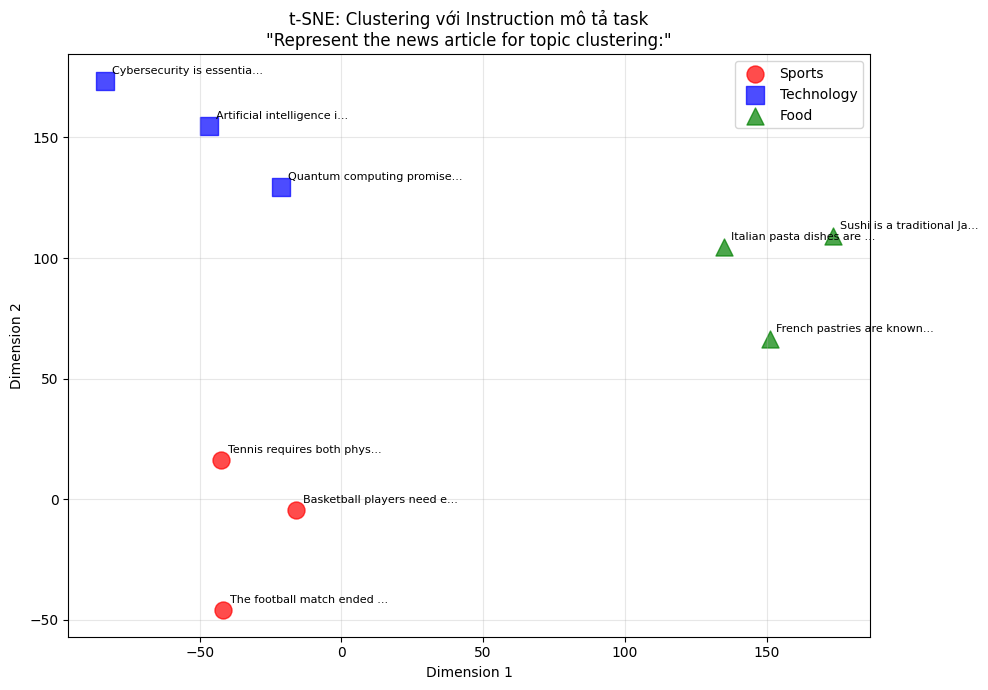


→ Với instruction mô tả task clustering, các văn bản cùng chủ đề được nhóm gần nhau!


In [11]:
from sklearn.manifold import TSNE

# Sử dụng embeddings đã tạo từ clustering demo
tsne = TSNE(n_components=2, random_state=42, perplexity=3)
emb_2d = tsne.fit_transform(embeddings_cluster)

plt.figure(figsize=(10, 7))
colors_map = {0: 'red', 1: 'blue', 2: 'green'}
markers = {0: 'o', 1: 's', 2: '^'}

for i, (x, y, label) in enumerate(zip(emb_2d[:, 0], emb_2d[:, 1], true_labels)):
    plt.scatter(x, y, c=colors_map[label], marker=markers[label], s=150, alpha=0.7,
                label=label_names[label] if i % 3 == 0 else "")
    plt.annotate(texts[i][:25] + "...", (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.title('t-SNE: Clustering với Instruction mô tả task\n"Represent the news article for topic clustering:"', fontsize=12)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n→ Với instruction mô tả task clustering, các văn bản cùng chủ đề được nhóm gần nhau!")